# Formative 1: Time Series Data Pipeline — Task 2: Databases (MySQL & MongoDB)
**Group 1** | Machine learning Pipeline | 5/7/2026

**Notebook owner:** Heroine Mutumwinka
**Responsibility:** MySQL schema (3 tables + ERD + indexes), data seeding, 3 SQL queries; MongoDB collection design, document insertion, 3 aggregation queries.

Part of a 4-notebook pipeline: `01_eda_preprocessing` → `02_modeling` → `03_databases` → `04_api_and_pipeline`.
Full end-to-end version: `00_full_pipeline.ipynb`. GitHub: https://github.com/Elvin100s/time-series-pipeline/tree/main


**Requires:** `MYSQL_*` and `MONGO_URI` Colab secrets.
**Seeds the cloud databases consumed by notebook 04.**
---

# Building a Pipeline for Time Series Data
## Power Consumption of Tétouan City, Morocco

**Dataset:** [Power Consumption of Tetouan City](https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption) — Kaggle / [UCI ML Repository](https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city)

**Description:** 52,416 observations recorded every 10 minutes across three distribution zones (Quads, Smir, Boussafou) in Tétouan, northern Morocco. Includes weather variables and solar diffuse flow measurements. Full year 2017.

The dataset is loaded programmatically using `kagglehub`, which handles authentication and caching automatically in Google Colab.

**Prediction Target:** Total power consumption (sum of all three zones)

---

### Contents
1. **Task 1** — Time-Series Preprocessing & Exploratory Analysis
2. **Task 2** — Database Design (SQL & MongoDB)
3. **Task 3** — CRUD Endpoints for Time-Series Queries
4. **Task 4** — Prediction / Forecast Script

## 1.1 Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')
sns.set_palette('deep')
print("Libraries loaded.")

Libraries loaded.


In [2]:
!pip install -q kagglehub

import kagglehub
import os, glob

try:
    path = kagglehub.dataset_download("fedesoriano/electric-power-consumption")
    print("Downloaded to:", path)
    csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
    print("CSV files found:", csv_files)
    CSV_PATH = csv_files[0]
    print("Using:", CSV_PATH)
except Exception as e:
    print("kagglehub download failed:", e)
    print("Run the fallback cell below instead.")
    CSV_PATH = None

100%|██████████| 1.36M/1.36M [00:00<00:00, 99.7MB/s]

Extracting files...
Downloaded to: /root/.cache/kagglehub/datasets/fedesoriano/electric-power-consumption/versions/1
CSV files found: ['/root/.cache/kagglehub/datasets/fedesoriano/electric-power-consumption/versions/1/powerconsumption.csv']
Using: /root/.cache/kagglehub/datasets/fedesoriano/electric-power-consumption/versions/1/powerconsumption.csv


In [3]:
import os
if 'CSV_PATH' not in dir() or not os.path.exists(CSV_PATH):
    print("Falling back to GitHub mirror (no Kaggle auth needed)...")
    CSV_PATH = 'powerconsumption.csv'
    !wget -q -O {CSV_PATH} "https://raw.githubusercontent.com/sunny2309/datasets/master/Tetuan%20City%20power%20consumption.csv"
    print("Downloaded to:", CSV_PATH)
else:
    print("kagglehub download already succeeded, skipping fallback.")

kagglehub download already succeeded, skipping fallback.


cleaning column names , finding datetime column and sanity check

In [4]:
df = pd.read_csv(CSV_PATH)


df.columns = [str(c).strip().replace('\ufeff', '') for c in df.columns]
print("Raw columns:", list(df.columns))


dt_col = next((c for c in df.columns if c.lower() in
               ('datetime', 'date_time', 'date', 'timestamp')), df.columns[0])
print("Detected datetime column:", dt_col)

df[dt_col] = pd.to_datetime(df[dt_col])
df = df.rename(columns={dt_col: 'DateTime'}).set_index('DateTime').sort_index()


assert df.shape[1] == 8, "Expected 8 feature columns, got {}: {}".format(df.shape[1], list(df.columns))

df.columns = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows',
              'DiffuseFlows', 'Zone1', 'Zone2', 'Zone3']
df['TotalConsumption'] = df['Zone1'] + df['Zone2'] + df['Zone3']

print("Shape:", df.shape)
print("Range:", df.index.min(), "to", df.index.max())
df.head()

Raw columns: ['Datetime', 'Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']
Detected datetime column: Datetime
Shape: (52416, 9)
Range: 2017-01-01 00:00:00 to 2017-12-30 23:50:00


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,Zone1,Zone2,Zone3,TotalConsumption
DateTime,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,70425.53544
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,69320.84387
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,67803.22193
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,65489.23209
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,63650.44627


> **Section lead:** Heroine Mutumwinka — Task 2. MySQL schema (3 tables + ERD + indexes), data seeding, 3 SQL queries; MongoDB collection design, document insertion, 3 aggregation queries (see commit history in the repository).

### Entity Relationship Diagram (ERD)

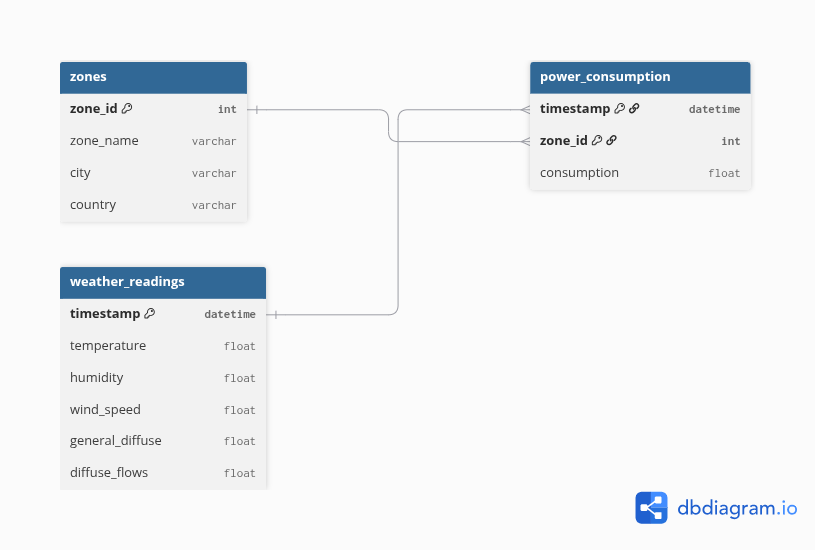


### MySQL Connection Setup

**Credentials are loaded from Colab's Secrets manager — never hardcoded.** This keeps them out of the notebook file itself, so it's safe to push to GitHub.

**One-time setup in Colab:**
1. Click the key icon (🔑) in the left sidebar → "Secrets"
2. Add 4 secrets: `MYSQL_HOST`, `MYSQL_USER`, `MYSQL_PASSWORD`, `MYSQL_DATABASE`
3. Toggle "Notebook access" on for each
4. Run the cell below — it reads them automatically, nothing to edit

In [5]:
!pip install -q mysql-connector-python

import mysql.connector
import os

try:
    from google.colab import userdata
    MYSQL_CONFIG = {
        'host':     userdata.get('MYSQL_HOST').strip(),
        'user':     userdata.get('MYSQL_USER').strip(),
        'password': userdata.get('MYSQL_PASSWORD').strip(),
        'database': userdata.get('MYSQL_DATABASE').splitlines()[0].strip(),
    }
except ImportError:

    MYSQL_CONFIG = {
        'host':     os.environ['MYSQL_HOST'],
        'user':     os.environ['MYSQL_USER'],
        'password': os.environ['MYSQL_PASSWORD'],
        'database': os.environ['MYSQL_DATABASE'],
    }


conn = mysql.connector.connect(**MYSQL_CONFIG)
cur = conn.cursor()
print("Connected to MySQL:", MYSQL_CONFIG['host'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 48.4 MB/s eta 0:00:00
Connected to MySQL: sql7.freesqldatabase.com


### Schema Scripts

Here I am going to drop existing tables inclundin zonez ,weather readings , power consumption

In [6]:

cur.execute('DROP TABLE IF EXISTS power_consumption')
cur.execute('DROP TABLE IF EXISTS weather_readings')
cur.execute('DROP TABLE IF EXISTS zones')

# Table 1: zones (dimension table)
cur.execute('''
    CREATE TABLE zones (
        zone_id      INT PRIMARY KEY,
        zone_name    VARCHAR(50) NOT NULL,
        station      VARCHAR(100) NOT NULL,
        description  TEXT
    )
''')

# Table 2: weather_readings (fact table)
cur.execute('''
    CREATE TABLE weather_readings (
        reading_id       INT AUTO_INCREMENT PRIMARY KEY,
        timestamp        DATETIME NOT NULL,
        temperature      FLOAT NOT NULL,
        humidity         FLOAT NOT NULL,
        wind_speed       FLOAT NOT NULL,
        general_diffuse  FLOAT NOT NULL,
        diffuse_flows    FLOAT NOT NULL,
        INDEX idx_w_ts (timestamp)
    )
''')

# Table 3: power_consumption (fact table)
cur.execute('''
    CREATE TABLE power_consumption (
        consumption_id  INT AUTO_INCREMENT PRIMARY KEY,
        zone_id         INT NOT NULL,
        timestamp       DATETIME NOT NULL,
        consumption     FLOAT NOT NULL,
        FOREIGN KEY (zone_id) REFERENCES zones(zone_id),
        INDEX idx_c_ts (timestamp),
        INDEX idx_c_zone (zone_id)
    )
''')

conn.commit()
print("MySQL schema created (3 tables + indexes).")

MySQL schema created (3 tables + indexes).


### Seed Data
for inserting zone metadata,resample to hourly for manageable BD size

In [7]:

cur.executemany(
    'INSERT INTO zones (zone_id, zone_name, station, description) VALUES (%s,%s,%s,%s)',
    [
        (1, 'Zone 1', 'Quads',     'Northern — highest consumption, commercial district'),
        (2, 'Zone 2', 'Smir',      'Central — mixed residential/commercial'),
        (3, 'Zone 3', 'Boussafou', 'Southern — primarily residential'),
    ]
)


h = df.resample('1h').mean().reset_index()


w_rows = [(r.DateTime.strftime('%Y-%m-%d %H:%M:%S'),
           round(r.Temperature,3), round(r.Humidity,3),
           round(r.WindSpeed,3), round(r.GeneralDiffuseFlows,3),
           round(r.DiffuseFlows,3)) for r in h.itertuples()]
cur.executemany(
    'INSERT INTO weather_readings (timestamp,temperature,humidity,'
    'wind_speed,general_diffuse,diffuse_flows) VALUES (%s,%s,%s,%s,%s,%s)', w_rows)


c_rows = []
for r in h.itertuples():
    ts = r.DateTime.strftime('%Y-%m-%d %H:%M:%S')
    c_rows.append((1, ts, round(r.Zone1, 3)))
    c_rows.append((2, ts, round(r.Zone2, 3)))
    c_rows.append((3, ts, round(r.Zone3, 3)))
cur.executemany(
    'INSERT INTO power_consumption (zone_id,timestamp,consumption) VALUES (%s,%s,%s)', c_rows)

conn.commit()
print("Seeded {} weather readings, {} consumption records.".format(len(w_rows), len(c_rows)))

Seeded 8736 weather readings, 26208 consumption records.


### SQL Queries

In [8]:
print("QUERY 1: Average consumption per zone")
print("-" * 60)
cur.execute('''
    SELECT z.zone_name, z.station,
           ROUND(AVG(pc.consumption),2) AS avg_c,
           ROUND(MIN(pc.consumption),2) AS min_c,
           ROUND(MAX(pc.consumption),2) AS max_c
    FROM power_consumption pc
    JOIN zones z ON pc.zone_id = z.zone_id
    GROUP BY z.zone_id ORDER BY avg_c DESC
''')
for row in cur.fetchall():
    print("  {} ({}):  avg={:>10}  min={:>10}  max={:>10}".format(*row))

QUERY 1: Average consumption per zone
------------------------------------------------------------
  Zone 1 (Quads):  avg=  32344.97  min=  14329.11  max=  51844.26
  Zone 2 (Smir):  avg=  21042.51  min=   8685.95  max=   36254.7
  Zone 3 (Boussafou):  avg=  17835.41  min=   6190.64  max=  47223.77


In [9]:
print("QUERY 2: Top 10 hottest hours + total consumption")
print("-" * 60)
cur.execute('''
    SELECT w.timestamp, w.temperature,
           ROUND(SUM(pc.consumption),2) AS total
    FROM weather_readings w
    JOIN power_consumption pc ON w.timestamp = pc.timestamp
    GROUP BY w.timestamp ORDER BY w.temperature DESC LIMIT 10
''')
for row in cur.fetchall():
    print("  {}  {:.1f} C  {:>12} kWh".format(row[0], row[1], row[2]))

QUERY 2: Top 10 hottest hours + total consumption
------------------------------------------------------------
  2017-07-21 14:00:00  39.7 C      95138.99 kWh
  2017-07-21 15:00:00  39.7 C       93419.8 kWh
  2017-07-21 16:00:00  39.1 C      92334.75 kWh
  2017-07-21 13:00:00  39.0 C      95885.38 kWh
  2017-07-21 17:00:00  38.7 C      91655.02 kWh
  2017-07-21 12:00:00  37.8 C      95711.91 kWh
  2017-07-21 18:00:00  37.6 C      93320.26 kWh
  2017-07-27 12:00:00  37.2 C     107053.04 kWh
  2017-07-10 15:00:00  36.9 C      93847.66 kWh
  2017-07-18 16:00:00  36.6 C      96573.25 kWh


In [10]:
print("QUERY 3: Monthly avg consumption by zone")
print("-" * 60)
month_names = 'Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec'.split()
cur.execute('''
    SELECT MONTH(pc.timestamp) AS m, z.zone_name,
           ROUND(AVG(pc.consumption),2) AS avg_c
    FROM power_consumption pc
    JOIN zones z ON pc.zone_id = z.zone_id
    GROUP BY m, z.zone_name ORDER BY m, z.zone_name
''')
for row in cur.fetchall():
    print("  {} {:<8} {:>10}".format(month_names[row[0]-1], row[1], row[2]))

QUERY 3: Monthly avg consumption by zone
------------------------------------------------------------
  Jan Zone 1     31032.49
  Jan Zone 2     19394.44
  Jan Zone 3      17746.1
  Feb Zone 1     30985.75
  Feb Zone 2     18787.79
  Feb Zone 3      17335.0
  Mar Zone 1     31155.17
  Mar Zone 2     18457.94
  Mar Zone 3     16947.69
  Apr Zone 1     31169.77
  Apr Zone 2     17633.97
  Apr Zone 3     18593.17
  May Zone 1     32396.01
  May Zone 2     19977.29
  May Zone 3      17621.1
  Jun Zone 1     34605.54
  Jun Zone 2     20670.93
  Jun Zone 3     20430.94
  Jul Zone 1     35831.55
  Jul Zone 2     24147.89
  Jul Zone 3     28194.11
  Aug Zone 1     36435.19
  Aug Zone 2     24656.22
  Aug Zone 3     24648.89
  Sep Zone 1     33396.68
  Sep Zone 2     20180.43
  Sep Zone 3      14922.8
  Oct Zone 1     32827.66
  Oct Zone 2     21468.99
  Oct Zone 3      13264.1
  Nov Zone 1     29002.11
  Nov Zone 2     23240.46
  Nov Zone 3      12862.5
  Dec Zone 1     29024.17
  Dec Zone 2  

## 2.2 MongoDB Collection (MongoDB Atlas)

Using **MongoDB Atlas** free-tier (M0 cluster). The document schema is denormalized — each document is one hourly reading with weather and zone consumption nested.

**Credentials are loaded from Colab's Secrets manager** (same approach as MySQL above).

**One-time setup in Colab:**
1. Key icon (🔑) in the left sidebar → "Secrets"
2. Add a secret named `MONGO_URI` with your full Atlas connection string as the value
3. Toggle "Notebook access" on

### MongoDB Connection & Document Insertion

In [11]:
!pip install -q pymongo

from pymongo import MongoClient
import json, os

try:
    from google.colab import userdata
    MONGO_URI = userdata.get('MONGO_URI')
except ImportError:
    MONGO_URI = os.environ['MONGO_URI']

mongo_client = MongoClient(MONGO_URI)
mdb = mongo_client['tetouan_power']
coll = mdb['readings']


coll.drop()

h = df.resample('1h').mean().reset_index()
docs = []
for r in h.itertuples():
    docs.append({
        'timestamp': r.DateTime.isoformat(),
        'weather': {
            'temperature': round(r.Temperature,3),
            'humidity': round(r.Humidity,3),
            'wind_speed': round(r.WindSpeed,3),
            'general_diffuse': round(r.GeneralDiffuseFlows,3),
            'diffuse_flows': round(r.DiffuseFlows,3),
        },
        'consumption': {
            'zone1': round(r.Zone1,3),
            'zone2': round(r.Zone2,3),
            'zone3': round(r.Zone3,3),
            'total': round(r.Zone1+r.Zone2+r.Zone3,3),
        },
        'metadata': {'city':'Tetouan','country':'Morocco','freq':'hourly'},
    })
coll.insert_many(docs)
print("Inserted {} documents into MongoDB Atlas.".format(len(docs)))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 15.7 MB/s eta 0:00:00
Inserted 8736 documents into MongoDB Atlas.


### Sample Document

In [12]:
sample = coll.find_one({}, {'_id': 0})
print(json.dumps(sample, indent=2, default=str))

{
  "timestamp": "2017-01-01T00:00:00",
  "weather": {
    "temperature": 6.197,
    "humidity": 75.067,
    "wind_speed": 0.082,
    "general_diffuse": 0.064,
    "diffuse_flows": 0.099
  },
  "consumption": {
    "zone1": 29197.975,
    "zone2": 18026.748,
    "zone3": 19252.048,
    "total": 66476.771
  },
  "metadata": {
    "city": "Tetouan",
    "country": "Morocco",
    "freq": "hourly"
  }
}


### MongoDB Queries

In [13]:
print("MONGO Q1: Summer averages (Jun-Aug)")
pipeline = [
    {'$match': {'timestamp': {'$gte': '2017-06-01', '$lt': '2017-09-01'}}},
    {'$group': {'_id': None,
                'avg_temp': {'$avg': '$weather.temperature'},
                'avg_total': {'$avg': '$consumption.total'},
                'count': {'$sum': 1}}}
]
for r in coll.aggregate(pipeline):
    print("  {} records | Avg temp: {:.1f} C | Avg total: {:,.0f} kWh".format(
        r['count'], r['avg_temp'], r['avg_total']))

MONGO Q1: Summer averages (Jun-Aug)
  2208 records | Avg temp: 25.1 C | Avg total: 83,289 kWh


In [14]:
print("MONGO Q2: Top 5 peak consumption")
for r in coll.find({}, {'_id':0,'timestamp':1,'consumption.total':1,'weather.temperature':1}
                  ).sort('consumption.total', -1).limit(5):
    print("  {} | {:>10,.0f} kWh | {:.1f} C".format(
        r['timestamp'], r['consumption']['total'], r['weather']['temperature']))

MONGO Q2: Top 5 peak consumption
  2017-07-24T20:00:00 |    133,130 kWh | 28.8 C
  2017-07-27T20:00:00 |    132,694 kWh | 27.8 C
  2017-07-25T20:00:00 |    132,330 kWh | 26.9 C
  2017-07-26T20:00:00 |    132,071 kWh | 33.3 C
  2017-07-24T21:00:00 |    129,515 kWh | 27.5 C


In [15]:
print("MONGO Q3: 24-hour consumption profile")
all_d = list(coll.find({}, {'_id':0,'timestamp':1,'consumption.total':1}))
ddf = pd.DataFrame(all_d)
ddf['hour'] = pd.to_datetime(ddf['timestamp']).dt.hour
ddf['total'] = ddf['consumption'].apply(lambda x: x['total'])
profile = ddf.groupby('hour')['total'].mean()
for h, v in profile.items():
    bar = '#' * int(v / 3000)
    print("  {:02d}:00  {:>10,.0f} kWh  {}".format(h, v, bar))

MONGO Q3: 24-hour consumption profile
  00:00      68,567 kWh  ######################
  01:00      62,301 kWh  ####################
  02:00      59,004 kWh  ###################
  03:00      56,629 kWh  ##################
  04:00      54,929 kWh  ##################
  05:00      51,639 kWh  #################
  06:00      50,190 kWh  ################
  07:00      51,425 kWh  #################
  08:00      56,907 kWh  ##################
  09:00      63,844 kWh  #####################
  10:00      69,823 kWh  #######################
  11:00      73,880 kWh  ########################
  12:00      75,588 kWh  #########################
  13:00      75,961 kWh  #########################
  14:00      75,159 kWh  #########################
  15:00      73,799 kWh  ########################
  16:00      72,691 kWh  ########################
  17:00      76,790 kWh  #########################
  18:00      86,141 kWh  ############################
  19:00      95,645 kWh  ###############################
  